In [32]:
import numpy as np
import matplotlib.pyplot as plt
from function_library_OOP import DetectorSetup 

In [33]:
directory = "Longitudinal_ImpactParameter_Plots"

rescaling_factor = 10**6   # 10^6 µm = 1 m

plt.rcParams["figure.figsize"] = (5,5)
xlabel = "$p_{T}$ [GeV/c]"
ylabel = "$\sigma_{z}$ [$\mu m$]"

### Global variables and detector initialization

In [34]:
spatial_resolution_ITS2 = 5 * 10**-6
average_layer_radii_ITS2 = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3               # average radius of ITS2 layers in meters
layerthickness_ITS2 = [0.0035, 0.0035, 0.0035, 0.0110, 0.0110, 0.0110, 0.0110]               # thickness of the detector planes in units of radiation length 0.35% X0 inner and 1.1% X0 outer
detector_resolutions_rphi_ITS2 = [spatial_resolution_ITS2 for i in range(7)]                 # spatial resolution of the ITS2 layers in rphi in meters
detector_resolutions_z_ITS2 = [spatial_resolution_ITS2 for i in range(7)]                    # spatial resolution of the ITS2  layers in z    in meters
radiation_length_air_ITS2 = 303.9                                                            # radiation length of air in meters
magnetic_field_strength_ITS2 = 0.5                                                           # strength of magnetic field in Alice in Tesla

ITS2 = DetectorSetup(average_layer_radii_ITS2, layerthickness_ITS2, detector_resolutions_rphi_ITS2, detector_resolutions_z_ITS2, radiation_length_air_ITS2, magnetic_field_strength_ITS2)

Detector Setup initialized


#### Proton:
- logintudinal impact parameter resolution
- for different extraplation radii (0.025, 0.075, 0.125) cm
- for different momenta ( 0 - 4 GeV/c)
- for different polar angles (90°, 67.5°, 45°)
- 4 hits in the outer layers of the ITS2

In [35]:
proton_momenta = np.arange(0.1, 4, 0.1)                     # momentum of particle in GeV/c
proton_mass = 1                                             # mass of particle in GeV/c^2 

N = 4                                                       # Number of layers with hits
extrapolation_radii = [0.025, 0.075, 0.125]                 # extrapolation length in meters (is defined away from layers) ;
theta_list = [90, 67.5, 45]                                 # polar angles of the particle

proton_z_4hits = np.array([[[ITS2.longitudinal_track_position_uncertainty(momentum, proton_mass, N, r, theta) for momentum in proton_momenta] for r in extrapolation_radii] for theta in theta_list])
proton_z_4hits.shape

np.set_printoptions(precision=8, suppress=True)
proton_z_4hits[0][2]

array([0.01438295, 0.00364875, 0.00166021, 0.00096341, 0.00064008,
       0.00046367, 0.0003566 , 0.00028647, 0.00023783, 0.00020254,
       0.000176  , 0.00015543, 0.0001391 , 0.00012585, 0.00011492,
       0.00010575, 0.00009797, 0.00009127, 0.00008546, 0.00008036,
       0.00007586, 0.00007186, 0.00006827, 0.00006505, 0.00006212,
       0.00005946, 0.00005703, 0.0000548 , 0.00005275, 0.00005086,
       0.0000491 , 0.00004747, 0.00004595, 0.00004453, 0.0000432 ,
       0.00004195, 0.00004078, 0.00003968, 0.00003864])

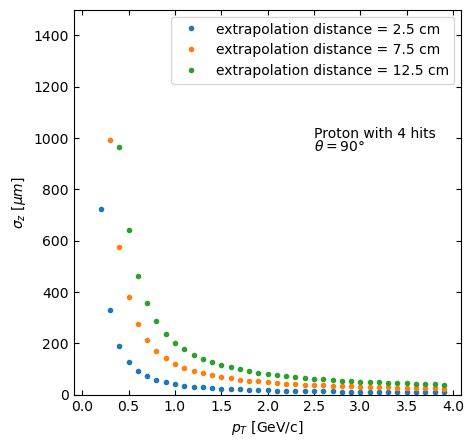

In [36]:
for i, r in enumerate(extrapolation_radii):
    plt.plot(proton_momenta, proton_z_4hits[0][i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
plt.legend()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.ylim(0, 1500)
plt.text(2.5, 1000, "Proton with 4 hits")
plt.text(2.5, 950, fr"$\theta = {theta_list[0]}$°")
plt.tick_params(top=True, right=True, direction="in")
plt.savefig(f"{directory}/Proton_z.png", dpi = 200)

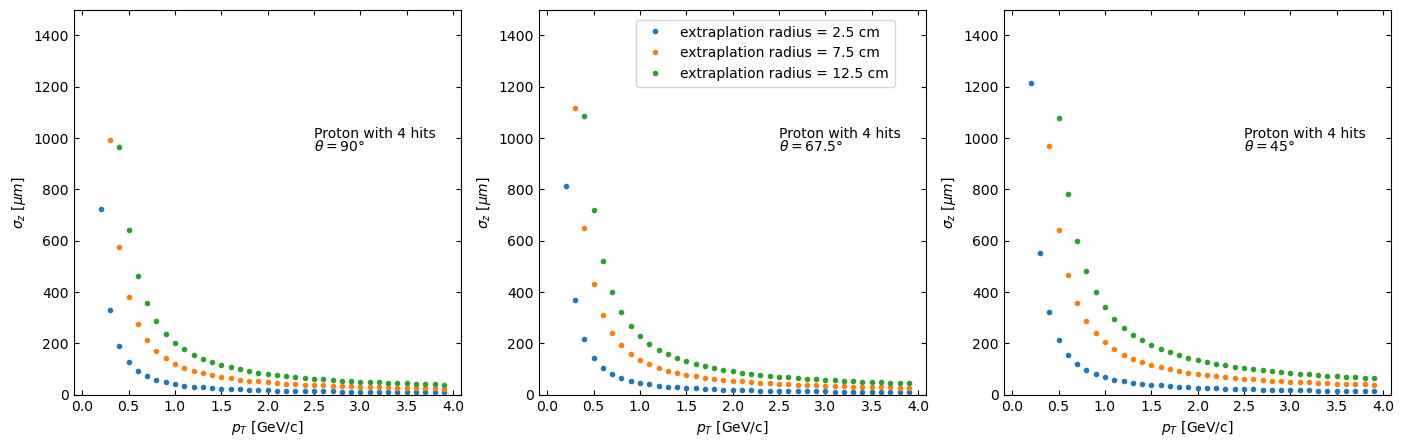

In [37]:
fig, axs = plt.subplots(1,3, figsize=(17,5))

for i, theta in enumerate(theta_list):
    for j, radius in enumerate(extrapolation_radii):
        axs[i].plot(proton_momenta, proton_z_4hits[i][j]*rescaling_factor, ".", label=f"extraplation radius = {radius*100} cm")

for i, ax in enumerate(axs):
    ax.set(xlabel = xlabel, ylabel = ylabel, ylim=(0, 1500))
    ax.tick_params(top=True, right=True, direction="in")
    ax.text(2.5, 1000, "Proton with 4 hits")
    ax.text(2.5, 950, fr"$\theta = {theta_list[i]}$°")

axs[1].legend(loc=(0.25, 0.8))
fig.savefig(f"{directory}/Proton_z_angle.png", dpi = 200)

#### Pion:
- longitudinal impact parameter resolution
- for different extraplation radii (0.025, 0.075, 0.125) cm
- for different momenta ( 0 - 1 GeV/c)
- for different polar angles (90°, 67.5°, 45°)
- 4 hits in the outer layers of the ITS2

In [38]:
pion_momenta = np.arange(0.1, 1.0, 0.02)                         # momentum of particle in GeV/c
pion_mass = 0.150                                                # mass of particle in GeV/c^2 

N = 4                                                            # Number of layers with hits
extrapolation_radii = [0.025, 0.075, 0.125]                      # extrapolation length in meters (is defined away from layers) ;
theta_list = [90, 67.5, 45]                                      # polar angles of the particle

pion_z_4hits = np.array([[[ITS2.longitudinal_track_position_uncertainty(momentum, pion_mass, N, r, theta) for momentum in pion_momenta] for r in extrapolation_radii] for theta in theta_list])

pion_z_4hits[0][2]

array([0.00258006, 0.00190916, 0.00149823, 0.00122611, 0.001035  ,
       0.0008945 , 0.00078738, 0.00070324, 0.00063553, 0.0005799 ,
       0.00053341, 0.00049399, 0.00046013, 0.00043074, 0.00040497,
       0.00038219, 0.00036191, 0.00034373, 0.00032733, 0.00031247,
       0.00029893, 0.00028654, 0.00027517, 0.00026468, 0.00025498,
       0.00024598, 0.00023761, 0.0002298 , 0.0002225 , 0.00021566,
       0.00020923, 0.00020318, 0.00019748, 0.00019209, 0.000187  ,
       0.00018217, 0.00017759, 0.00017324, 0.0001691 , 0.00016515,
       0.00016139, 0.0001578 , 0.00015436, 0.00015108, 0.00014793])

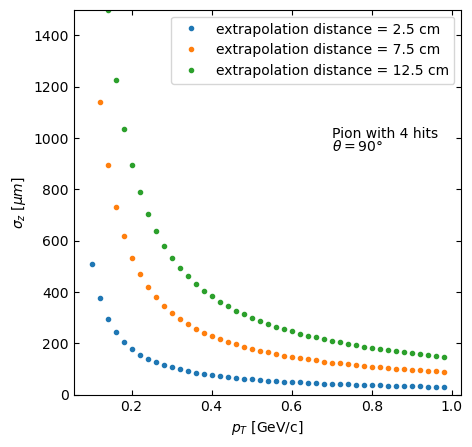

In [39]:
for i, r in enumerate(extrapolation_radii):
    plt.plot(pion_momenta, pion_z_4hits[0][i]*rescaling_factor, ".", label=f"extrapolation distance = {r*100} cm")
plt.legend()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.ylim(0, 1500)
plt.text(0.7, 1000, "Pion with 4 hits")
plt.text(0.7, 950, fr"$\theta = {theta_list[0]}$°")
plt.tick_params(top=True, right=True, direction="in")
plt.savefig(f"{directory}/Pion_z.png", dpi = 200)

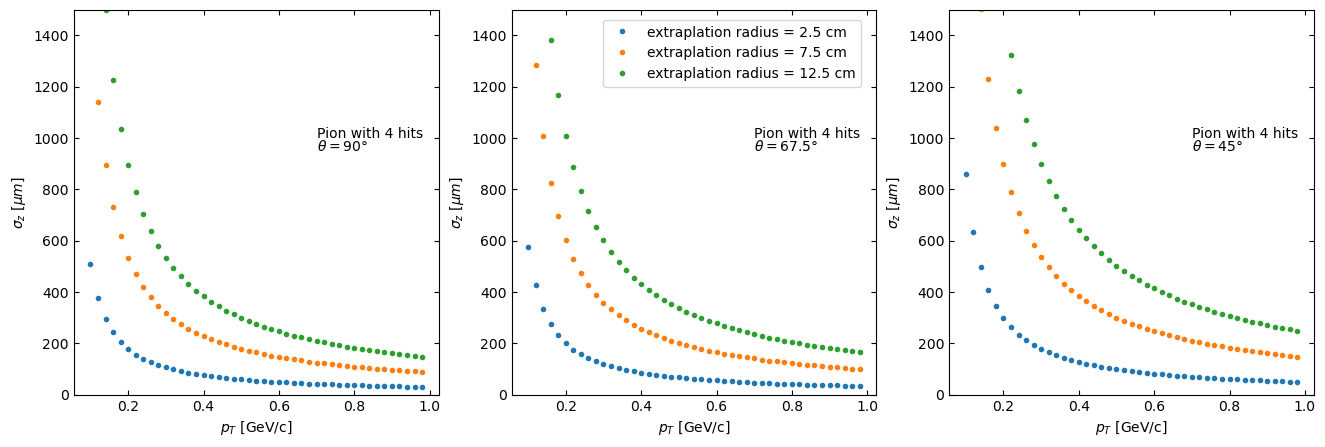

In [40]:
fig, axs = plt.subplots(1,3, figsize=(16,5))

for i, theta in enumerate(theta_list):
    for j, radius in enumerate(extrapolation_radii):
        axs[i].plot(pion_momenta, pion_z_4hits[i][j]*rescaling_factor, ".", label=f"extraplation radius = {radius*100} cm")

for i, ax in enumerate(axs):
    ax.set(xlabel = xlabel, ylabel = ylabel, ylim=(0, 1500))
    ax.tick_params(top=True, right=True, direction="in")
    ax.text(0.7, 1000, "Pion with 4 hits")
    ax.text(0.7, 950, fr"$\theta = {theta_list[i]}$°")

axs[1].legend(loc=(0.25, 0.8))
fig.savefig(f"{directory}/Pion_z_angle.png", dpi = 200)

#### Proton:
- longitudinal impact parameter resolution
- for different extraplation radii 1 cm
- for different momenta ( 0 - 4 GeV/c )
- for different polar angles (90°, 67.5°, 45°)
- ### 7 hits in the ITS2

In [41]:
proton_momenta = np.arange(0.2, 4, 0.1)                     # momentum of particle in GeV/c
proton_mass = 1                                             # mass of particle in GeV/c^2 

N = 7                                                       # Number of layers with hits
extrapolation_radius = 0.01                                 # extrapolation length in meters (is defined away from layers) ;
theta_list = [90, 67.5, 45]                                 # polar angles of the particle

proton_z_7hits = np.array([[ITS2.longitudinal_track_position_uncertainty(momentum, proton_mass, N, extrapolation_radius, theta) for momentum in proton_momenta] for theta in theta_list])
proton_z_7hits.shape

(3, 38)

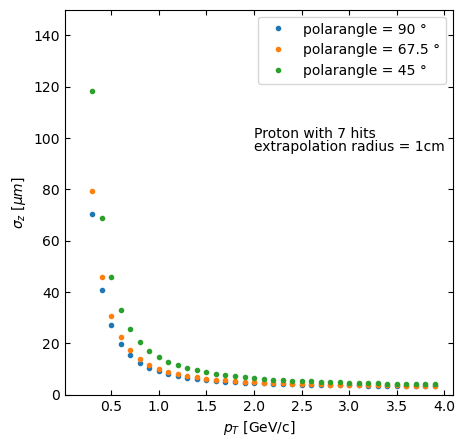

In [42]:
for i, theta in enumerate(theta_list):
    plt.plot(proton_momenta, proton_z_7hits[i]*rescaling_factor, ".", label=f"polarangle = {theta} °")
plt.legend()
plt.ylim(0, 150)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.text(2, 100, "Proton with 7 hits")
plt.text(2, 95, "extrapolation radius = 1cm")
plt.tick_params(top=True, right=True, direction="in")
plt.savefig(f"{directory}/Proton_z_7.png", dpi = 200)

#### Pion:
- longitudinal impact parameter resolution
- for different extraplation radii 1 cm
- for different momenta ( 0 - 1 GeV/c)
- for different polar angles (90°, 67.5°, 45°)
- #### 7 hits in the ITS2

In [43]:
pion_momenta = np.arange(0.1, 1.1, 0.02)                    # momentum of particle in GeV/c
pion_mass = 0.150                                           # mass of particle in GeV/c^2 

N = 7                                                       # Number of layers with hits
extrapolation_radius = 0.01                                 # extrapolation length in meters (is defined away from layers) ;
theta_list = [90, 67.5, 45]                                 # polar angles of the particle

pion_z_7hits = np.array([[ITS2.longitudinal_track_position_uncertainty(momentum, pion_mass, N, extrapolation_radius, theta) for momentum in pion_momenta] for theta in theta_list])

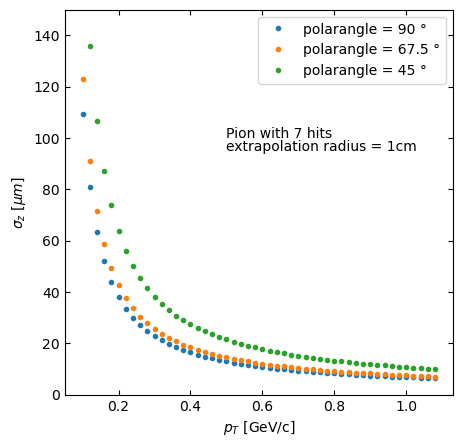

In [44]:
for i, theta in enumerate(theta_list):
    plt.plot(pion_momenta, pion_z_7hits[i]*rescaling_factor, ".", label=f"polarangle = {theta} °")
plt.legend()
plt.ylim(0, 150)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.text(0.5, 100, "Pion with 7 hits")
plt.text(0.5, 95, "extrapolation radius = 1cm")
plt.tick_params(top=True, right=True, direction="in")
plt.savefig(f"{directory}/Pion_z_7.png", dpi = 200)